Loading AB Dataset...
Loading AA Dataset...
Comparing 10 trials from AB vs 10 trials from AA.
Correlation between conditions: 0.8802


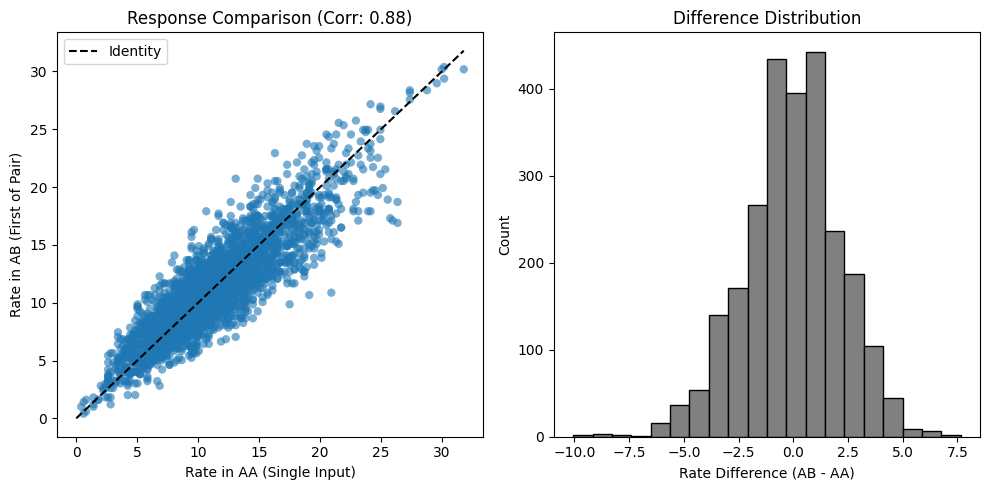

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mozaik.storage.datastore import PickledDataStore
from parameters import ParameterSet
from mozaik.storage.queries import param_filter_query

# ==========================================
# 1. Load Data
# ==========================================

# Dataset 1: AB (20 segments -> 2 inputs/trial)
print("Loading AB Dataset...")
ds_ab = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": "SelfSustainedPushPull_test:AB12_____", "store_stimuli": False}),
    replace=False
)
dsv_ab = param_filter_query(ds_ab, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
segs_ab = dsv_ab.get_segments()

# Dataset 2: AA (10 segments -> 1 input/trial)
print("Loading AA Dataset...")
ds_aa = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": "SelfSustainedPushPull_test:AA12_____", "store_stimuli": False}),
    replace=False
)
dsv_aa = param_filter_query(ds_aa, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
segs_aa = dsv_aa.get_segments()

# ==========================================
# 2. Select Segments by Index
# ==========================================
# AB: Take every 2nd segment (Indices 0, 2, 4... correspond to the FIRST input of the pair)
segs_A_from_AB = segs_ab[0::2] 

# AA: Take all segments (Indices 0, 1, 2... correspond to the ONLY input)
segs_A_from_AA = segs_aa[:]

print(f"Comparing {len(segs_A_from_AB)} trials from AB vs {len(segs_A_from_AA)} trials from AA.")

# ==========================================
# 3. Calculate Mean Firing Rates
# ==========================================
def calculate_rates(segments):
    """
    Returns a dictionary {neuron_id: mean_firing_rate_hz} averaged across trials.
    """
    unit_rates = {} # {id: [rate_trial_1, rate_trial_2, ...]}
    
    for seg in segments:
        duration_sec = (seg.t_stop - seg.t_start).rescale('s').magnitude
        
        for st in seg.spiketrains:
            # Mozaik stores neuron ID in annotations 'source_id'
            # If not present, fallback to neo name or index logic (assuming consistent sorting)
            uid = st.annotations.get('source_id', st.name)
            
            rate = len(st) / duration_sec
            
            if uid not in unit_rates:
                unit_rates[uid] = []
            unit_rates[uid].append(rate)
            
    # Average across trials
    return {k: np.mean(v) for k, v in unit_rates.items()}

rates_AB = calculate_rates(segs_A_from_AB)
rates_AA = calculate_rates(segs_A_from_AA)

# ==========================================
# 4. Compare and Plot
# ==========================================
# Align neurons by ID
neuron_ids = sorted(rates_AA.keys())
values_AB = [rates_AB[uid] for uid in neuron_ids if uid in rates_AB]
values_AA = [rates_AA[uid] for uid in neuron_ids if uid in rates_AB]

# Statistics
corr = np.corrcoef(values_AA, values_AB)[0, 1]
print(f"Correlation between conditions: {corr:.4f}")

# Plot
plt.figure(figsize=(10, 5))

# Scatter
plt.subplot(1, 2, 1)
plt.scatter(values_AA, values_AB, alpha=0.6, edgecolors='none')
plt.plot([0, max(values_AA)], [0, max(values_AA)], 'k--', label="Identity")
plt.xlabel("Rate in AA (Single Input)")
plt.ylabel("Rate in AB (First of Pair)")
plt.title(f"Response Comparison (Corr: {corr:.2f})")
plt.legend()

# Histogram of differences
plt.subplot(1, 2, 2)
diffs = np.array(values_AB) - np.array(values_AA)
plt.hist(diffs, bins=20, color='gray', edgecolor='black')
plt.xlabel("Rate Difference (AB - AA)")
plt.ylabel("Count")
plt.title("Difference Distribution")

plt.tight_layout()
plt.show()

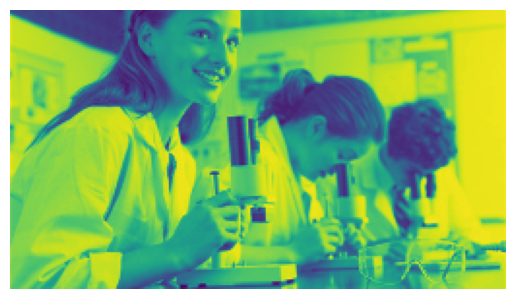

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a 10x10 "image" with random colors
# Shape: (Height, Width, Channels) where Channels are R, G, B
data = np.load("/data/dynamic29513-my-images-AB/screen/data/00008.npy")

# 2. Visualize using Matplotlib
plt.imshow(data)
plt.axis('off') # Hide the X and Y pixel coordinates
plt.show()

In [14]:
!ls /data

 dummy			        dynamic29513-my-images-AB
 dummy2			        dynamic29513-my-test
 dummy_data		        dynamic29513-two-test
 dynamic29513-3-5-Video-full    monkey_data
'dynamic29513-my-images copy'   my_data.zip
 dynamic29513-my-images-AA      my_dataset_with_meta
